# Package installation

In [2]:
#%pip install numpy
#%pip install pillow
#%pip install matplotlib
#%pip install tensorflow
#%pip install mpmath
#%pip install galois

%pip install scikit-image

  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
   ---------------------------------------- 0.0/11.9 MB ? eta -:--:--
   ---------------------------------------  11.8/11.9 MB 64.3 MB/s eta 0:00:01
   ---------------------------------------- 11.9/11.9 MB 60.1 MB/s  0:00:00
Using cached networkx-3.6.1-py3-none-any.whl (2.1 MB)
   ---------------------------------------- 0.0/36.6 MB ? eta -:--:--
   -------------------------- ------------- 24.4/36.6 MB 118.5 MB/s eta 0:00:01
   ---------------------------------------- 36.6/36.6 MB 107.4 MB/s  0:00:00

   ---------------------------------------- 0/6 [tifffile]
   ---------------------------------------- 0/6 [tifffile]
   ------ --------------------------------- 1/6 [scipy]
   ------ --------------------------------- 1/6 [scipy]
   ------ --------------------------------- 1/6 [scipy]
   ------ --------------------------------- 1/6 [scipy]
   ------ --------------------------------- 1/6 [scipy]
   ------ --------------------

In [ ]:
# import numpy as np
# from PIL import Image
# from itertools import permutations
# from typing import List
# from itertools import permutations
# import matplotlib.pyplot as plt
# import secrets
# import galois

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'error'
Note: you may need to restart the kernel to use updated packages.


  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> [3 lines of output]
      
      *** Please install the `scikit-image` package (instead of `skimage`) ***
      
      [end of output]
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
ERROR: Failed to build 'skimage' when getting requirements to build wheel


# ALgorith preparation

# Cipher Implementation Algorithm

In [ ]:
import numpy as np
import galois
from PIL import Image
import itertools

# Inicialización estricta del Campo de Galois de 8 bits
GF = galois.GF(256)

# ---------------------------------------------------------
# FASE 0: PLANO DE CONTROL CAÓTICO (LORENZ 3D VIA RK4)
# ---------------------------------------------------------
def lorenz_derivadas(x, y, z, sigma=10.0, rho=28.0, beta=8/3):
    dxdt = sigma * (y - x)
    dydt = x * (rho - z) - y
    dzdt = x * y - beta * z
    return dxdt, dydt, dzdt

def generar_fase_0_lorenz(num_pasos, dt=0.01, x0=0.1, y0=0.1, z0=0.1):
    x = np.zeros(num_pasos)
    y = np.zeros(num_pasos)
    z = np.zeros(num_pasos)
    
    x[0], y[0], z[0] = x0, y0, z0
    
    for t in range(num_pasos - 1):
        k1_x, k1_y, k1_z = lorenz_derivadas(x[t], y[t], z[t])
        k2_x, k2_y, k2_z = lorenz_derivadas(x[t] + 0.5*dt*k1_x, y[t] + 0.5*dt*k1_y, z[t] + 0.5*dt*k1_z)
        k3_x, k3_y, k3_z = lorenz_derivadas(x[t] + 0.5*dt*k2_x, y[t] + 0.5*dt*k2_y, z[t] + 0.5*dt*k2_z)
        k4_x, k4_y, k4_z = lorenz_derivadas(x[t] + dt*k3_x, y[t] + dt*k3_y, z[t] + dt*k3_z)
        
        x[t+1] = x[t] + (dt / 6.0) * (k1_x + 2 * k2_x + 2 * k3_x + k4_x)
        y[t+1] = y[t] + (dt / 6.0) * (k1_y + 2 * k2_y + 2 * k3_y + k4_y)
        z[t+1] = z[t] + (dt / 6.0) * (k1_z + 2 * k2_z + 2 * k3_z + k4_z)
        
    return x, y, z

# ---------------------------------------------------------
# CONSTRUCCIÓN DEL BANCO DE 24 MATRICES 4x4 EN GF(2^8)
# ---------------------------------------------------------
def construir_banco_24_matrices_gf(secuencia_y) -> list:
    y_bytes = np.floor((np.abs(secuencia_y) - np.floor(np.abs(secuencia_y))) * 256).astype(np.uint8)
    
    sub_A = GF(y_bytes[0:4].reshape(2, 2))
    sub_B = GF(y_bytes[4:8].reshape(2, 2))
    sub_C = GF(y_bytes[8:12].reshape(2, 2))
    sub_D = GF(y_bytes[12:16].reshape(2, 2))
    
    submatrices = [sub_A, sub_B, sub_C, sub_D]
    banco_24 = []
    
    for perm in itertools.permutations(submatrices):
        fila_sup = np.block([perm[0], perm[1]])
        fila_inf = np.block([perm[2], perm[3]])
        matriz_4x4 = GF(np.vstack([fila_sup, fila_inf]))
        
        offset = 1
        while np.linalg.det(matriz_4x4) == 0:
            matriz_4x4[0, 0] += offset
            offset += 1
            
        banco_24.append(matriz_4x4)
        
    return banco_24

# ---------------------------------------------------------
# FASE 2.5: CAPA DE ACOPLAMIENTO CUÁNTICO-INSPIRADO MULTINIVEL
# ---------------------------------------------------------
def obtener_matriz_qft_3x3_gf() -> tuple:
    omega = None
    for el in GF.elements:
        if el != 0 and el != 1 and (el**3) == 1:
            omega = el
            break
            
    F3 = GF([
        [1, 1, 1],
        [1, omega, omega**2],
        [1, omega**2, omega]
    ])
    
    F3_inv = np.linalg.inv(F3)
    return F3, F3_inv

def acoplamiento_inter_canal_ida(R_flat, G_flat, B_flat, F3) -> tuple:
    R_gf = GF(R_flat)
    G_gf = GF(G_flat)
    B_gf = GF(B_flat)
    
    B_t = B_gf + (R_gf * G_gf)
    R_s, G_s = G_gf.copy(), R_gf.copy()
    R_c = R_s + B_t
    
    matriz_3xN = GF(np.vstack([R_c, G_s, B_t]))
    matriz_difundida = F3 @ matriz_3xN
    
    return np.asarray(matriz_difundida[0]), np.asarray(matriz_difundida[1]), np.asarray(matriz_difundida[2])

# ---------------------------------------------------------
# FASE 5: MODULACIÓN DE FASE + DIFUSIÓN EN CASCADA CNOT
# ---------------------------------------------------------
def fase5_modulation_cifrar(R_flat, G_flat, B_flat, Z_caos):
    R_gf = GF(R_flat)
    G_gf = GF(G_flat)
    B_gf = GF(B_flat)
    
    Z_bytes = np.floor((np.abs(Z_caos) - np.floor(np.abs(Z_caos))) * 256).astype(np.uint8)
    z_gf = GF(Z_bytes[:len(R_flat)])
    
    R_cif = GF(np.zeros(len(R_flat), dtype=np.uint8))
    G_cif = GF(np.zeros(len(G_flat), dtype=np.uint8))
    B_cif = GF(np.zeros(len(B_flat), dtype=np.uint8))
    
    # Condición de frontera para el elemento 0 (Modulación de fase inicial local)
    R_cif[0] = R_gf[0] + z_gf[0] * G_gf[0]
    G_cif[0] = G_gf[0]
    B_cif[0] = B_gf[0] + z_gf[0] * R_gf[0]
        
    for j in range(1, len(R_flat)):
        r_fase = R_gf[j] + z_gf[j] * G_gf[j]
        g_fase = G_gf[j]
        b_fase = B_gf[j] + z_gf[j] * R_gf[j]
            
        R_cif[j] = r_fase + B_cif[j-1]
        G_cif[j] = g_fase + R_cif[j-1]
        B_cif[j] = b_fase + G_cif[j-1]
        
    return np.asarray(R_cif), np.asarray(G_cif), np.asarray(B_cif)

# ---------------------------------------------------------
# OPERACIONES COMPLEMENTARIAS DE OPERADORES BIYECTIVOS
# ---------------------------------------------------------
def permutacion_global_pixeles(canal_2d: np.ndarray, indices_args: np.ndarray) -> np.ndarray:
    h, w = canal_2d.shape
    canal_plano = canal_2d.flatten()
    idx_adaptados = indices_args[:len(canal_plano)]
    return canal_plano[idx_adaptados].reshape((h, w))

def canal_a_bloques_gf(canal_arr: np.ndarray) -> galois.FieldArray:
    arr = canal_arr.flatten()
    pad = (4 - len(arr) % 4) % 4
    if pad:
        arr = np.concatenate([arr, np.zeros(pad, dtype=arr.dtype)])
    return GF(arr.reshape(4, -1))

def cifrar_bloques_en_cascada_gf(bloques_canal, banco_matrices, secuencia_x) -> galois.FieldArray:
    resultado = GF(bloques_canal.copy())
    num_columnas = bloques_canal.shape[1]
    
    x_indices = np.floor((np.abs(secuencia_x) - np.floor(np.abs(secuencia_x))) * 1000).astype(np.int32)
    
    for col in range(num_columnas):
        idx_matriz = x_indices[col % len(x_indices)] % 24
        M_seleccionada = banco_matrices[idx_matriz]
        resultado[:, col] = M_seleccionada @ resultado[:, col]
        
    return resultado


def cifrar_pipeline(path : str, dt : float, x : float, y : float, z : float):
    img = Image.open(path).convert("RGB")
    img = Image.open(path).convert("RGB")
    h, w = img.height, img.width
    total_pixeles = h * w

    R_arr, G_arr, B_arr = np.array(img.split()[0]), np.array(img.split()[1]), np.array(img.split()[2])

    X_caos, Y_caos, Z_caos = generar_fase_0_lorenz(num_pasos=max(total_pixeles, 1000), dt=dt, x0=x, y0=y, z0=z)
    banco_24 = construir_banco_24_matrices_gf(Y_caos)
    indices_caoticos_z = np.argsort(Z_caos)

    # --- ETAPA A: Permutación Espacial ---
    R_p = permutacion_global_pixeles(R_arr, indices_caoticos_z)
    G_p = permutacion_global_pixeles(G_arr, indices_caoticos_z)
    B_p = permutacion_global_pixeles(B_arr, indices_caoticos_z)

    # --- ETAPA 2.5: Acoplamiento Cuántico multinivel ---
    F3, _ = obtener_matriz_qft_3x3_gf()
    R_acop, G_acop, B_acop = acoplamiento_inter_canal_ida(R_p.flatten(), G_p.flatten(), B_p.flatten(), F3)

    # --- ETAPA B: Bloques Galois ---
    R_bloques = canal_a_bloques_gf(R_acop.reshape(h, w))
    G_bloques = canal_a_bloques_gf(G_acop.reshape(h, w))
    B_bloques = canal_a_bloques_gf(B_acop.reshape(h, w))

    # --- ETAPA C: Cascada Matricial ---
    c_r = cifrar_bloques_en_cascada_gf(R_bloques, banco_24, X_caos)
    c_g = cifrar_bloques_en_cascada_gf(G_bloques, banco_24, X_caos)
    c_b = cifrar_bloques_en_cascada_gf(B_bloques, banco_24, X_caos)

    c_r_2d = np.asarray(c_r).reshape(-1)[:total_pixeles].reshape(h, w)
    c_g_2d = np.asarray(c_g).reshape(-1)[:total_pixeles].reshape(h, w)
    c_b_2d = np.asarray(c_b).reshape(-1)[:total_pixeles].reshape(h, w)

    # --- FASE 5: Modulación de Fase + Red CNOT Avalancha (O(N)) ---
    r_f_flat, g_f_flat, b_f_flat = fase5_modulation_cifrar(c_r_2d.flatten(), c_g_2d.flatten(), c_b_2d.flatten(), Z_caos)
    
    r_final = r_f_flat.reshape(h, w)
    g_final = g_f_flat.reshape(h, w)
    b_final = b_f_flat.reshape(h, w)

    cifrado_visual = np.stack([r_final, g_final, b_final], axis=2).astype(np.uint8)
    ruta_guardado = r"./Imagenes/cifrado.png"
    Image.fromarray(cifrado_visual, mode="RGB").save(ruta_guardado)

    print(f"¡Cifrado Completado! Criptograma guardado en: {ruta_guardado}")
    
# ---------------------------------------------------------
# PIPELINE DE EJECUCIÓN PRINCIPAL (CIFRADO)
# ---------------------------------------------------------
if __name__ == "__main__":    
    # 1. Carga de la Imagen de Entrada
    path = r"./Imagenes/4.2.03.png"
    cifrar_pipeline(path, 0.01, 0.01, 0.01, 0.01)

¡Cifrado Completado! Criptograma guardado en: ./Imagenes/cifrado.png


## Inverse Path

In [30]:
import numpy as np
import galois
from PIL import Image
import itertools

# Inicialización estricta del Campo de Galois de 8 bits
GF = galois.GF(256)

# ---------------------------------------------------------
# FASE 0: PLANO DE CONTROL CAÓTICO (LORENZ 3D VIA RK4)
# ---------------------------------------------------------
def lorenz_derivadas(x, y, z, sigma=10.0, rho=28.0, beta=8/3):
    dxdt = sigma * (y - x)
    dydt = x * (rho - z) - y
    dzdt = x * y - beta * z
    return dxdt, dydt, dzdt

def generar_fase_0_lorenz(num_pasos, dt=0.01, x0=0.1, y0=0.1, z0=0.1):
    x = np.zeros(num_pasos)
    y = np.zeros(num_pasos)
    z = np.zeros(num_pasos)
    
    x[0], y[0], z[0] = x0, y0, z0
    
    for t in range(num_pasos - 1):
        k1_x, k1_y, k1_z = lorenz_derivadas(x[t], y[t], z[t])
        k2_x, k2_y, k2_z = lorenz_derivadas(x[t] + 0.5*dt*k1_x, y[t] + 0.5*dt*k1_y, z[t] + 0.5*dt*k1_z)
        k3_x, k3_y, k3_z = lorenz_derivadas(x[t] + 0.5*dt*k2_x, y[t] + 0.5*dt*k2_y, z[t] + 0.5*dt*k2_z)
        k4_x, k4_y, k4_z = lorenz_derivadas(x[t] + dt*k3_x, y[t] + dt*k3_y, z[t] + dt*k3_z)
        
        x[t+1] = x[t] + (dt / 6.0) * (k1_x + 2 * k2_x + 2 * k3_x + k4_x)
        y[t+1] = y[t] + (dt / 6.0) * (k1_y + 2 * k2_y + 2 * k3_y + k4_y)
        z[t+1] = z[t] + (dt / 6.0) * (k1_z + 2 * k2_z + 2 * k3_z + k4_z)
        
    return x, y, z

# ---------------------------------------------------------
# CONSTRUCCIÓN DEL BANCO DE 24 MATRICES 4x4 EN GF(2^8)
# ---------------------------------------------------------
def construir_banco_24_matrices_gf(secuencia_y) -> list:
    y_bytes = np.floor((np.abs(secuencia_y) - np.floor(np.abs(secuencia_y))) * 256).astype(np.uint8)
    
    sub_A = GF(y_bytes[0:4].reshape(2, 2))
    sub_B = GF(y_bytes[4:8].reshape(2, 2))
    sub_C = GF(y_bytes[8:12].reshape(2, 2))
    sub_D = GF(y_bytes[12:16].reshape(2, 2))
    
    submatrices = [sub_A, sub_B, sub_C, sub_D]
    banco_24 = []
    
    for perm in itertools.permutations(submatrices):
        fila_sup = np.block([perm[0], perm[1]])
        fila_inf = np.block([perm[2], perm[3]])
        matriz_4x4 = GF(np.vstack([fila_sup, fila_inf]))
        
        offset = 1
        while np.linalg.det(matriz_4x4) == 0:
            matriz_4x4[0, 0] += offset
            offset += 1
            
        banco_24.append(matriz_4x4)
        
    return banco_24

# ---------------------------------------------------------
# FASE 2.5 INVERSA: DESACOPLAMIENTO CUÁNTICO MULTINIVEL
# ---------------------------------------------------------
def obtener_matriz_qft_3x3_gf() -> tuple:
    omega = None
    for el in GF.elements:
        if el != 0 and el != 1 and (el**3) == 1:
            omega = el
            break
            
    F3 = GF([
        [1, 1, 1],
        [1, omega, omega**2],
        [1, omega**2, omega]
    ])
    
    F3_inv = np.linalg.inv(F3)
    return F3, F3_inv

def acoplamiento_inter_canal_vuelta(R_cif, G_cif, B_cif, F3_inv) -> tuple:
    matriz_cifrada = GF(np.vstack([R_cif, G_cif, B_cif]))
    
    matriz_recuperada = F3_inv @ matriz_cifrada
    R_c = matriz_recuperada[0]
    G_s = matriz_recuperada[1]
    B_t = matriz_recuperada[2]
    
    R_s = R_c + B_t
    R_gf, G_gf = G_s.copy(), R_s.copy()
    B_original = B_t + (R_gf * G_gf)
    
    return np.asarray(R_gf), np.asarray(G_gf), np.asarray(B_original)

# ---------------------------------------------------------
# FASE 5 INVERSA: DESFASE Y DES-ENCADENAMIENTO EN REVERSA
# ---------------------------------------------------------
def fase5_modulation_descifrar(R_cif, G_cif, B_cif, Z_caos):
    R_gf = GF(R_cif)
    G_gf = GF(G_cif)
    B_gf = GF(B_cif)
    
    Z_bytes = np.floor((np.abs(Z_caos) - np.floor(np.abs(Z_caos))) * 256).astype(np.uint8)
    z_gf = GF(Z_bytes[:len(R_cif)])
    
    R_fase = GF(np.zeros(len(R_cif), dtype=np.uint8))
    G_fase = GF(np.zeros(len(G_cif), dtype=np.uint8))
    B_fase = GF(np.zeros(len(B_cif), dtype=np.uint8))
    
    # Deshacer la cascada CNOT en reversa estricta (LIFO) de N-1 hasta 1
    for j in range(len(R_cif) - 1, 0, -1):
        R_fase[j] = R_gf[j] + B_gf[j-1]
        G_fase[j] = G_gf[j] + R_gf[j-1]
        B_fase[j] = B_gf[j] + G_gf[j-1]
        
    # Condición de frontera para el elemento inicial
    R_fase[0] = R_gf[0]
    G_fase[0] = G_gf[0]
    B_fase[0] = B_gf[0]
    
    # Desmodular la fase local multiplicando por la inversa de corte
    R_dec = R_fase + z_gf * G_fase
    G_dec = G_fase
    B_dec = B_fase + z_gf * R_fase + (z_gf**2) * G_fase
    
    return np.asarray(R_dec), np.asarray(G_dec), np.asarray(B_dec)

# ---------------------------------------------------------
# OPERACIONES COMPLEMENTARIAS DE OPERADORES BIYECTIVOS
# ---------------------------------------------------------
def inversa_permutacion_global(canal_2d_cifrado: np.ndarray, indices_args: np.ndarray) -> np.ndarray:
    h, w = canal_2d_cifrado.shape
    canal_plano = canal_2d_cifrado.flatten()
    idx_adaptados = indices_args[:len(canal_plano)]
    idx_inverso = np.argsort(idx_adaptados)
    return canal_plano[idx_inverso].reshape((h, w))

def canal_a_bloques_gf(canal_arr: np.ndarray) -> galois.FieldArray:
    arr = canal_arr.flatten()
    pad = (4 - len(arr) % 4) % 4
    if pad:
        arr = np.concatenate([arr, np.zeros(pad, dtype=arr.dtype)])
    return GF(arr.reshape(4, -1))

def descifrar_bloques_en_cascada_gf(bloques_cifrados, banco_matrices, secuencia_x) -> galois.FieldArray:
    resultado = GF(bloques_cifrados.copy())
    num_columnas = bloques_cifrados.shape[1]
    
    x_indices = np.floor((np.abs(secuencia_x) - np.floor(np.abs(secuencia_x))) * 1000).astype(np.int32)
    
    for col in range(num_columnas):
        idx_matriz = x_indices[col % len(x_indices)] % 24
        M_seleccionada = banco_matrices[idx_matriz]
        M_inversa = np.linalg.inv(M_seleccionada)
        resultado[:, col] = M_inversa @ resultado[:, col]
        
    return resultado

def descifrar_pipeline(path : str, dt : int, x : int, y : int, z : int):
    img_cifrada = Image.open(path).convert("RGB")
    h, w = img_cifrada.height, img_cifrada.width
    total_pixeles = h * w

    C_R, C_G, C_B = img_cifrada.split()
    C_R_arr, C_G_arr, C_B_arr = np.array(C_R), np.array(C_G), np.array(C_B)

    X_caos, Y_caos, Z_caos = generar_fase_0_lorenz(num_pasos=max(total_pixeles, 1000), dt=dt,x0=x, y0=y, z0=z)
    banco_24 = construir_banco_24_matrices_gf(Y_caos)
    indices_caoticos_z = np.argsort(Z_caos)

    print("Iniciando proceso de descifrado inverso...")

    # --- REVERTIR FASE 5: Desmodulación de Fase y Des-encadenamiento (Reversa LIFO) ---
    r_desmod, g_desmod, b_desmod = fase5_modulation_descifrar(C_R_arr.flatten(), C_G_arr.flatten(), C_B_arr.flatten(), Z_caos)

    # --- REVERTIR ETAPA C: Bloques Galois y Descifrado Matricial ---
    R_bloques_cifrados = canal_a_bloques_gf(r_desmod)
    G_bloques_cifrados = canal_a_bloques_gf(g_desmod)
    B_bloques_cifrados = canal_a_bloques_gf(b_desmod)

    R_bloques_dec = descifrar_bloques_en_cascada_gf(R_bloques_cifrados, banco_24, X_caos)
    G_bloques_dec = descifrar_bloques_en_cascada_gf(G_bloques_cifrados, banco_24, X_caos)
    B_bloques_dec = descifrar_bloques_en_cascada_gf(B_bloques_cifrados, banco_24, X_caos)

    R_dec_flat = np.asarray(R_bloques_dec).reshape(-1)[:total_pixeles]
    G_dec_flat = np.asarray(G_bloques_dec).reshape(-1)[:total_pixeles]
    B_dec_flat = np.asarray(B_bloques_dec).reshape(-1)[:total_pixeles]

    # --- REVERTIR ETAPA 2.5: Desacoplamiento Cuántico-Inspirado ---
    _, F3_inv = obtener_matriz_qft_3x3_gf()
    R_desacop, G_desacop, B_desacop = acoplamiento_inter_canal_vuelta(R_dec_flat, G_dec_flat, B_dec_flat, F3_inv)

    R_dec_2d = R_desacop.reshape(h, w)
    G_dec_2d = G_desacop.reshape(h, w)
    B_dec_2d = B_desacop.reshape(h, w)

    # --- REVERTIR ETAPA A: Deshacer Permutación Espacial ---
    R_original = inversa_permutacion_global(R_dec_2d, indices_caoticos_z)
    G_original = inversa_permutacion_global(G_dec_2d, indices_caoticos_z)
    B_original = inversa_permutacion_global(B_dec_2d, indices_caoticos_z)

    imagen_recuperada = np.stack([R_original, G_original, B_original], axis=2).astype(np.uint8)
    ruta_recuperada = r"./Imagenes/recuperada.png"
    Image.fromarray(imagen_recuperada, mode="RGB").save(ruta_recuperada)

    print(f"¡Descifrado exitoso! Imagen restaurada en: {ruta_recuperada}")

# ---------------------------------------------------------
# PIPELINE DE EJECUCIÓN PRINCIPAL (DESCIFRADO)
# ---------------------------------------------------------
if __name__ == "__main__":
    x0_key, y0_key, z0_key = 0.01, 0.01, 0.01
    ruta_cifrada = r"./Imagenes/cifrado.png"
    descifrar_pipeline(ruta_cifrada, 0.01, x0_key, y0_key, z0_key)


Iniciando proceso de descifrado inverso...
¡Descifrado exitoso! Imagen restaurada en: ./Imagenes/recuperada.png


## Test Preparation

In [4]:
import numpy as np
from PIL import Image
import os

def generar_banco_pruebas_nist(ruta_imagen_original, ruta_txt_salida, ruta_bin_salida, cantidad_bitstreams=100):
    print("--- INICIANDO GENERACIÓN DE BANCO DE PRUEBAS NIST (100 BITSTREAMS) ---")
    
    # 1. Cargar la imagen base una sola vez
    img = Image.open(ruta_imagen_original).convert("RGB")
    h, w = img.height, img.width
    total_pixeles = h * w
    
    # Configurar Lorenz para la cantidad de píxeles
    num_pasos_lorenz = max(total_pixeles, 1000)
    
    # Definimos la llave base de Lorenz
    x0_base, y0_base, z0_base = 0.1, 0.1, 0.1
    
    # Listas para acumular todos los bytes de las 100 ejecuciones
    bytes_acumulados = []
    
    # 2. Ciclo principal para encriptar con 100 llaves distintas
    for i in range(cantidad_bitstreams):
        # Generamos una variación infinitesimal en la condición inicial para cada iteración
        # Esto demuestra la sensibilidad al cambio de llave (Efecto Mariposa)
        x0_dinamico = x0_base + (i * 1e-7)
        
        # Ejecutar Fase 0
        X_caos, Y_caos, Z_caos = generar_fase_0_lorenz(num_pasos=num_pasos_lorenz, x0=x0_dinamico, y0=y0_base, z0=z0_base)
        
        # Reconstruir entorno criptográfico indexado
        banco_24 = construir_banco_24_matrices_gf(Y_caos)
        indices_caoticos_z = np.argsort(Z_caos)
        
        # --- ETAPA A: Permutación Espacial ---
        R_arr, G_arr, B_arr = np.array(img.split()[0]), np.array(img.split()[1]), np.array(img.split()[2])
        R_p = permutacion_global_pixeles(R_arr, indices_caoticos_z)
        G_p = permutacion_global_pixeles(G_arr, indices_caoticos_z)
        B_p = permutacion_global_pixeles(B_arr, indices_caoticos_z)
        
        # --- ETAPA 2.5: Acoplamiento Cuántico-Inspirado ---
        F3, _ = obtener_matriz_qft_3x3_gf()
        R_acop, G_acop, B_acop = acoplamiento_inter_canal_ida(R_p.flatten(), G_p.flatten(), B_p.flatten(), F3)
        
        # --- ETAPA B: Conversión a Bloques Galois ---
        R_bloques = canal_a_bloques_gf(R_acop.reshape(h, w))
        G_bloques = canal_a_bloques_gf(G_acop.reshape(h, w))
        B_bloques = canal_a_bloques_gf(B_acop.reshape(h, w))
        
        # --- ETAPA C: Cifrado Matricial en Cascada Continua ---
        c_r = cifrar_bloques_en_cascada_gf(R_bloques, banco_24, X_caos)
        c_g = cifrar_bloques_en_cascada_gf(G_bloques, banco_24, X_caos)
        c_b = cifrar_bloques_en_cascada_gf(B_bloques, banco_24, X_caos)
        
        # Reconstrucción de dimensiones espaciales removiendo el padding
        c_r_2d = np.asarray(c_r).reshape(-1)[:total_pixeles].reshape(h, w)
        c_g_2d = np.asarray(c_g).reshape(-1)[:total_pixeles].reshape(h, w)
        c_b_2d = np.asarray(c_b).reshape(-1)[:total_pixeles].reshape(h, w)
        
        # --- FASE 5: Modulación de Fase en Galois (Modulación cuántico-caótica) ---
        r_f_flat, g_f_flat, b_f_flat = fase5_modulation_cifrar(c_r_2d.flatten(), c_g_2d.flatten(), c_b_2d.flatten(), Z_caos)
        
        # --- PROCESO DE APLANADO PARA EL BLOQUE ACTUAL ---
        # Concatenamos los tres canales cifrados de esta iteración
        bytes_criptograma_actual = np.concatenate([r_f_flat, g_f_flat, b_f_flat])
        bytes_acumulados.append(bytes_criptograma_actual)
        
        if (i + 1) % 10 == 0:
            print(f"  [Progreso] Cifradas {i + 1}/100 imágenes con llaves dinámicas.")

    # 3. Consolidar todas las iteraciones en un solo bloque lineal
    print("\n[Procesando] Unificando flujos binarios...")
    todos_los_bytes = np.concatenate(bytes_acumulados)
    
    # Desempaquetar los bits (de MSB a LSB) para el archivo de texto
    print("[Procesando] Desempaquetando bytes a bits para el reporte ASCII...")
    todos_los_bits = np.unpackbits(todos_los_bytes)
    
    total_bits_generados = len(todos_los_bits)
    print(f"  -> Total de bits consolidados: {total_bits_generados} bits.")
    
    # 4. Escritura estricta en disco (.bin y .txt)
    print(f"[Guardando] Escribiendo archivo binario en: {ruta_bin_salida}")
    with open(ruta_bin_salida, "wb") as f_bin:
        f_bin.write(todos_los_bytes.tobytes())
        
    print(f"[Guardando] Escribiendo archivo de texto plano en: {ruta_txt_salida}")
    cadena_bits = "".join(todos_los_bits.astype(str))
    with open(ruta_txt_salida, "w") as f_txt:
        f_txt.write(cadena_bits)
        
    print("\n--- ¡PROCESO COMPLETADO! BANCO DE PRUEBAS LISTO PARA EL NIST ---")

# ---------------------------------------------------------
# EJECUCIÓN
# ---------------------------------------------------------
if __name__ == "__main__":
    # Asegúrate de crear la carpeta 'data' en el directorio de sts-2.1.2 si usas rutas relativas
    ruta_origen = r"./Imagenes/4.2.03.png"
    ruta_nist_txt = r"C:/cygwin64/sts-2_1_2/sts-2.1.2/sts-2.1.2/data/nist_sequence_100.txt"
    ruta_nist_bin = r"C:/cygwin64/sts-2_1_2/sts-2.1.2/sts-2.1.2/data/nist_sequence_100.bin"
    
    generar_banco_pruebas_nist(ruta_origen, ruta_nist_txt, ruta_nist_bin, cantidad_bitstreams=100)

--- INICIANDO GENERACIÓN DE BANCO DE PRUEBAS NIST (100 BITSTREAMS) ---
  [Progreso] Cifradas 10/100 imágenes con llaves dinámicas.
  [Progreso] Cifradas 20/100 imágenes con llaves dinámicas.
  [Progreso] Cifradas 30/100 imágenes con llaves dinámicas.
  [Progreso] Cifradas 40/100 imágenes con llaves dinámicas.
  [Progreso] Cifradas 50/100 imágenes con llaves dinámicas.
  [Progreso] Cifradas 60/100 imágenes con llaves dinámicas.
  [Progreso] Cifradas 70/100 imágenes con llaves dinámicas.
  [Progreso] Cifradas 80/100 imágenes con llaves dinámicas.
  [Progreso] Cifradas 90/100 imágenes con llaves dinámicas.
  [Progreso] Cifradas 100/100 imágenes con llaves dinámicas.

[Procesando] Unificando flujos binarios...
[Procesando] Desempaquetando bytes a bits para el reporte ASCII...
  -> Total de bits consolidados: 629145600 bits.
[Guardando] Escribiendo archivo binario en: C:/cygwin64/sts-2_1_2/sts-2.1.2/sts-2.1.2/data/nist_sequence_100.bin
[Guardando] Escribiendo archivo de texto plano en: C:/c

## IMAGE TEST

Iniciando batería de pruebas...

--- INICIANDO PRUEBA DE OCLUSIÓN (128x128) ---
¡Cifrado Completado! Criptograma guardado en: ./Imagenes/cifrado.png
Iniciando proceso de descifrado inverso...
¡Descifrado exitoso! Imagen restaurada en: ./Imagenes/recuperada.png
Recuperación post-oclusión -> PSNR: 14.76 dB, SSIM: 0.3352


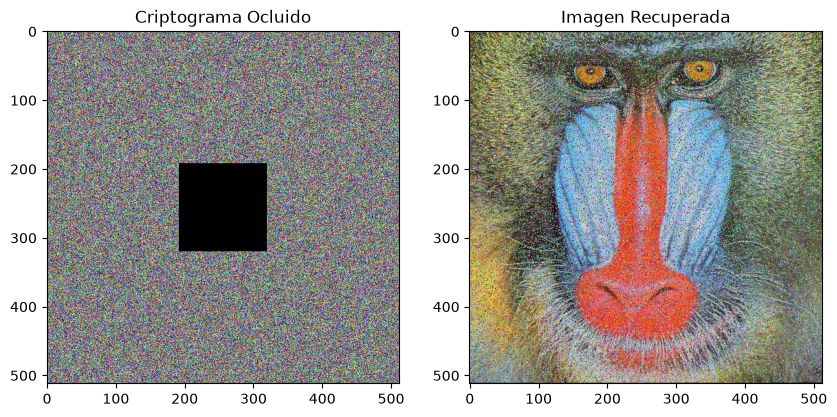


¡Pruebas finalizadas!


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr
import copy
import os

# =========================================================================
# CONFIGURACIÓN DE RUTAS Y PIPELINES
# =========================================================================
path_img = r"./Imagenes/4.2.03.png"
path_encr = r"./Imagenes/cifrado.png"
path_rec = r"./Imagenes/recuperada.png"
path_temp = r"./Imagenes/temp.png"  

# Aquí debes importar tus funciones reales:
# from tu_modulo import cifrar_pipeline, descifrar_pipeline

# =========================================================================
# 1. ANÁLISIS DIFERENCIAL (NPCR y UACI) - EFECTO AVALANCHA | NO FALLA 
# =========================================================================
def prueba_npcr_uaci(dt, x, y, z):
    print("\n--- INICIANDO PRUEBA NPCR Y UACI ---")

    # ==============================
    # 1. Cifrar imagen original
    # ==============================
    cifrar_pipeline(path_img, dt, x, y, z)
    C1 = np.array(Image.open(path_encr).convert("RGB"))

    # ==============================
    # 2. Modificar un solo bit
    # ==============================
    I1 = np.array(Image.open(path_img).convert("RGB"))
    I2 = I1.copy()

    print("\n--- Cambio realizado en la imagen original ---")
    print(f"Antes   : {I1[0,0,0]:08b} ({I1[0,0,0]})")

    # Cambiar únicamente el bit menos significativo
    I2[0, 0, 0] ^= 1

    print(f"Después : {I2[0,0,0]:08b} ({I2[0,0,0]})")
    print(f"XOR     : {(I1[0,0,0] ^ I2[0,0,0]):08b}")

    Image.fromarray(I2).save(path_temp)

    # ==============================
    # 3. Cifrar imagen modificada
    # ==============================
    cifrar_pipeline(path_temp, dt, x, y, z)
    C2 = np.array(Image.open(path_encr).convert("RGB"))

    assert C1.shape == C2.shape

    # ==============================
    # 4. Analizar diferencias
    # ==============================
    diff_matrix = np.abs(C1.astype(np.int16) - C2.astype(np.int16))

    print("\n--- Diferencia entre imágenes cifradas ---")
    print(f"Diferencia mínima   : {diff_matrix.min()}")
    print(f"Diferencia máxima   : {diff_matrix.max()}")
    print(f"Diferencia promedio : {diff_matrix.mean():.4f}")

    changed_components = np.count_nonzero(diff_matrix)
    total_components = diff_matrix.size

    print(f"Componentes diferentes: {changed_components}/{total_components}")
    print(f"Porcentaje de componentes diferentes: "
          f"{100 * changed_components / total_components:.4f}%")

    # Mostrar algunos cambios
    changed = (C1 != C2)
    coords = np.argwhere(changed)

    print("\nPrimeros 10 cambios encontrados:")
    for yy, xx, ch in coords[:10]:
        print(
            f"({yy}, {xx}, Canal {ch}) : "
            f"{C1[yy, xx, ch]} -> {C2[yy, xx, ch]} "
            f"(Δ={diff_matrix[yy, xx, ch]})"
        )

    # ==============================
    # 5. Calcular NPCR y UACI
    # ==============================
    h, w, c = C1.shape
    total_pixeles = h * w

    npcr_vals = []
    uaci_vals = []

    C1_float = C1.astype(np.float64)
    C2_float = C2.astype(np.float64)

    for ch in range(c):
        diff = np.abs(C1_float[:, :, ch] - C2_float[:, :, ch])
        D = (diff != 0).astype(np.float64)

        npcr = (np.sum(D) / total_pixeles) * 100
        uaci = (np.sum(diff) / (255.0 * total_pixeles)) * 100

        npcr_vals.append(npcr)
        uaci_vals.append(uaci)

    print("\n--- Resultados NPCR y UACI ---")
    print(
        f"NPCR (R,G,B): "
        f"{npcr_vals[0]:.4f}%, "
        f"{npcr_vals[1]:.4f}%, "
        f"{npcr_vals[2]:.4f}%"
    )

    print(
        f"UACI (R,G,B): "
        f"{uaci_vals[0]:.4f}%, "
        f"{uaci_vals[1]:.4f}%, "
        f"{uaci_vals[2]:.4f}%"
    )

    print(f"\nNPCR promedio: {np.mean(npcr_vals):.4f}%")
    print(f"UACI promedio: {np.mean(uaci_vals):.4f}%")

# =========================================================================
# 2. SENSIBILIDAD A LA LLAVE | NO FALLA
# =========================================================================
def prueba_sensibilidad_llave(dt, x, y, z):
    print("\n--- INICIANDO PRUEBA DE SENSIBILIDAD A LA LLAVE ---")
    
    # Llave con una alteración infinitesimal
    x_err = x + 1e-14
    
    # Cifrar con la llave correcta
    cifrar_pipeline(path_img, dt, x, y, z)
    
    # Descifrar usando la ruta del cifrado, pero con la llave incorrecta
    descifrar_pipeline(path_encr, dt, x_err, y, z)
    
    # Leer resultados
    I_org = np.array(Image.open(path_img).convert("RGB"))
    I_dec_err = np.array(Image.open(path_rec).convert("RGB"))
    
    ssim_val = ssim(I_org, I_dec_err, channel_axis=2)
    print(f"SSIM con llave alterada en 10^-15: {ssim_val:.6f} (Debería ser ~0)")
    
    plt.figure("Sensibilidad a la Llave", figsize=(10, 5))
    plt.subplot(1, 2, 1); plt.imshow(I_org); plt.title("Original")
    plt.subplot(1, 2, 2); plt.imshow(I_dec_err); plt.title(f"Descifrado Fallido (SSIM: {ssim_val:.4f})")
    plt.show()

# =========================================================================
# 3. ROBUSTEZ FRENTE A RUIDO (Sal y Pimienta) | NO FALLA
# =========================================================================
def prueba_ruido_sal_pimienta(dt, x, y, z, prob=0.05):
    print(f"\n--- INICIANDO PRUEBA DE RUIDO SAL Y PIMIENTA ({prob*100}%) ---")

    # 1. Generar criptograma original
    cifrar_pipeline(path_img, dt, x, y, z)
    C1 = np.array(Image.open(path_encr).convert("RGB"))

    # 2. Aplicar ruido Sal y Pimienta
    C_ruido = C1.copy()
    h, w, c = C_ruido.shape
    num_pixeles = int(prob * h * w)

    # Coordenadas aleatorias sin reemplazo
    indices = np.random.choice(h * w, size=num_pixeles, replace=False)
    filas, columnas = np.unravel_index(indices, (h, w))
    mitad = num_pixeles // 2
    C_ruido[filas[:mitad], columnas[:mitad], :] = 0
    C_ruido[filas[mitad:], columnas[mitad:], :] = 255

    print(f"Componentes modificados: {np.count_nonzero(C1 != C_ruido)}")

    Image.fromarray(C_ruido).save(path_temp)
    
    # 3. Descifrar el criptograma con ruido
    descifrar_pipeline(path_temp, dt, x, y, z)

    # 4. Leer imágenes
    I_org = np.array(Image.open(path_img).convert("RGB"))
    I_rec_ruido = np.array(Image.open(path_rec).convert("RGB"))

    # 5. Calcular MSE
    mse = np.mean(
        (I_org.astype(np.float64) - I_rec_ruido.astype(np.float64)) ** 2
    )

    # 6. Calcular PSNR evitando división por cero
    if mse == 0:
        psnr_val = float("inf")
    else:
        psnr_val = psnr(I_org, I_rec_ruido)

    # 7. Calcular SSIM
    ssim_val = ssim(I_org, I_rec_ruido, channel_axis=2)

    # 8. Mostrar resultados
    if np.isinf(psnr_val):
        print("Recuperación post-ruido -> PSNR: ∞ dB, SSIM: {:.4f}".format(ssim_val))
    else:
        print("Recuperación post-ruido -> PSNR: {:.2f} dB, SSIM: {:.4f}".format(psnr_val, ssim_val))

    # 9. Visualización
    plt.figure("Ataque de Ruido", figsize=(10, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(C_ruido)
    plt.title(f"Criptograma ({prob*100:.1f}% Ruido)")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(I_rec_ruido)
    plt.title("Imagen Recuperada")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

# =========================================================================
# 4. PRUEBA DE OCLUSIÓN (Data Loss) | NO FALLA
# =========================================================================
def prueba_oclusion(dt, x, y, z, bloque_size=200):
    print(f"\n--- INICIANDO PRUEBA DE OCLUSIÓN ({bloque_size}x{bloque_size}) ---")
    
    # Cifrado limpio
    cifrar_pipeline(path_img, dt, x, y, z)
    C1 = np.array(Image.open(path_encr).convert("RGB"))
    
    # Generar oclusión en el centro
    C_oclusion = copy.deepcopy(C1)
    h, w, c = C_oclusion.shape
    start_h, start_w = (h // 2) - (bloque_size // 2), (w // 2) - (bloque_size // 2)
    C_oclusion[start_h:start_h+bloque_size, start_w:start_w+bloque_size, :] = 0
    
    # Guardar criptograma ocluido y descifrar
    Image.fromarray(C_oclusion).save(path_temp)
    descifrar_pipeline(path_temp, dt, x, y, z)
    
    # Leer para métricas
    I_org = np.array(Image.open(path_img).convert("RGB"))
    I_rec_oclusion = np.array(Image.open(path_rec).convert("RGB"))
    
    psnr_val = psnr(I_org, I_rec_oclusion)
    ssim_val = ssim(I_org, I_rec_oclusion, channel_axis=2)
    
    print(f"Recuperación post-oclusión -> PSNR: {psnr_val:.2f} dB, SSIM: {ssim_val:.4f}")
    
    plt.figure("Ataque de Oclusión", figsize=(10, 5))
    plt.subplot(1, 2, 1); plt.imshow(C_oclusion); plt.title("Criptograma Ocluido")
    plt.subplot(1, 2, 2); plt.imshow(I_rec_oclusion); plt.title("Imagen Recuperada")
    plt.show()

# =========================================================================
# BLOQUE PRINCIPAL DE EJECUCIÓN
# =========================================================================
if __name__ == "__main__":
    param_dt = 0.01
    key_x, key_y, key_z = 0.1, 0.1, 0.1
    
    os.makedirs(os.path.dirname(path_img), exist_ok=True)
    
    print("Iniciando batería de pruebas...")
    prueba_oclusion(param_dt, key_x, key_y, key_z)
        
    print("\n¡Pruebas finalizadas!")    